In [156]:
import numpy as np
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.optimize import curve_fit
data_dir = '/home/kale-chen/Documents/PET/TimeCalibration/MiniPET/cal10.bin'
num_rows = os.path.getsize(data_dir) // 6
data = np.memmap(data_dir, dtype = np.int16, mode = 'r', shape=(num_rows, 3))
print(num_rows)

def gaussianbg(x, a, mu, c, bg):
    return a * np.exp(-(x - mu)**2 / (2 * c**2)) + bg

def gaussian(x, a, mu, c):
    return a * np.exp(-(x - mu)**2 / (2 * c**2))



31187


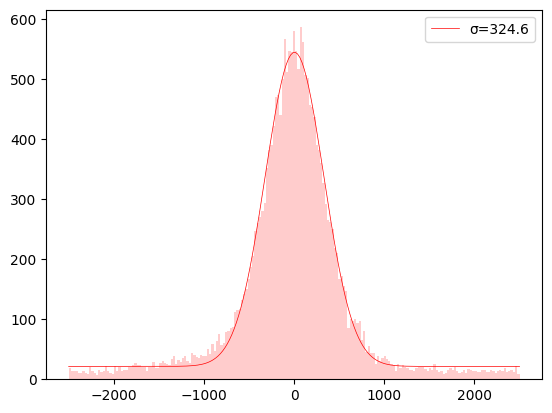

In [137]:
bins = np.linspace(-2500, 2500, 200)
bincenters = [(bins[n] + bins[n + 1]) / 2 for n in range(len(bins) - 1)]
hist = plt.hist(data[:, 2], bins = bins, color = 'red', alpha = 0.2)[0]
popt, pcov = curve_fit(gaussianbg, bincenters, hist, p0 = [10, 0, 500, 10])
plt.plot(bins, gaussianbg(bins, *popt), color = 'red', linewidth = 0.5, label = f'σ={abs(round(popt[2], 1))}')
plt.legend()
plt.show()


In [194]:
num_iterations = 112
bins = np.linspace(-10000, 10000, 100)
bincenters = [(bins[n] + bins[n + 1]) / 2 for n in range(len(bins) - 1)]

data_copy = data.copy()

existing_channels_L = np.unique(data_copy[:, 0])
existing_channels_R = np.unique(data_copy[:, 1])

for it in tqdm(range(num_iterations)):
    time_spreads_L = np.zeros(128)
    # Standard deviation of the time distributions from each channel
    for i in range(128):
        channelL = data_copy[data_copy[:, 0] == i]
        if len(channelL) > 0:
            hist = np.histogram(channelL[:, 2], bins = bins)[0]
            popt, pcov = curve_fit(gaussian, bincenters, hist, p0 = [5, 0, 500])
            time_spreads_L[i] = np.abs(popt[2])
        else:
            time_spreads_L[i] = 0

    # Remove largest spread channel
    max_spread_index = np.argmax(time_spreads_L)
    data_copy = data_copy[data_copy[:, 0] != max_spread_index]
    #print(max_spread_index)
    existing_channels_L = np.unique(data_copy[:, 0])
    time_spreads_R = np.zeros(128)
    for i in range(128):
        channelR = data_copy[data_copy[:, 1] == i]
        if len(channelR) > 0:
            hist = np.histogram(channelR[:, 2], bins = bins)[0]
            popt, pcov = curve_fit(gaussian, bincenters, hist, p0 = [5, 0, 500])
            time_spreads_R[i] = np.abs(popt[2])
        else:
            time_spreads_R[i] = 0

    # Remove largest spread channel
    max_spread_index = np.argmax(time_spreads_R)
    data_copy = data_copy[data_copy[:, 1] != max_spread_index]
    existing_channels_R = np.unique(data_copy[:, 1])
    #rint(max_spread_index)
    #break

# Remove any channels from data_copy whose spread is less than 50 for both L and R

# For left channels
channels_to_remove_L = []
for i in range(len(existing_channels_L)):
    if time_spreads_L[i] < 50 and time_spreads_L[i] > 0:
        channels_to_remove_L.append(existing_channels_L[i])
if channels_to_remove_L:
    data_copy = data_copy[~np.isin(data_copy[:, 0], channels_to_remove_L)]
    print(f"Removed L channels with spread < 50: {channels_to_remove_L}")
    existing_channels_L = np.unique(data_copy[:, 0])

# For right channels
channels_to_remove_R = []
for i in range(len(existing_channels_R)):
    if time_spreads_R[i] < 50 and time_spreads_R[i] > 0:
        channels_to_remove_R.append(existing_channels_R[i])
if channels_to_remove_R:
    data_copy = data_copy[~np.isin(data_copy[:, 1], channels_to_remove_R)]
    print(f"Removed R channels with spread < 50: {channels_to_remove_R}")
    existing_channels_R = np.unique(data_copy[:, 1])


print(len(existing_channels_L), len(existing_channels_R))
print(len(time_spreads_L), len(time_spreads_R))
print(len(data_copy))


    

  0%|          | 0/112 [00:00<?, ?it/s]/home/kale-chen/.pyenv/versions/3.12.3/lib/python3.12/site-packages/scipy/optimize/_minpack_py.py:498: RuntimeWarning: overflow encountered in matmul
  cov_x = invR @ invR.T
 23%|██▎       | 26/112 [00:01<00:05, 17.09it/s]/tmp/ipykernel_111740/2247090935.py:17: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(gaussian, bincenters, hist, p0 = [5, 0, 500])
 88%|████████▊ | 98/112 [00:04<00:00, 45.10it/s]/tmp/ipykernel_111740/2247090935.py:32: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(gaussian, bincenters, hist, p0 = [5, 0, 500])
100%|██████████| 112/112 [00:04<00:00, 26.00it/s]

16 15
128 128
306


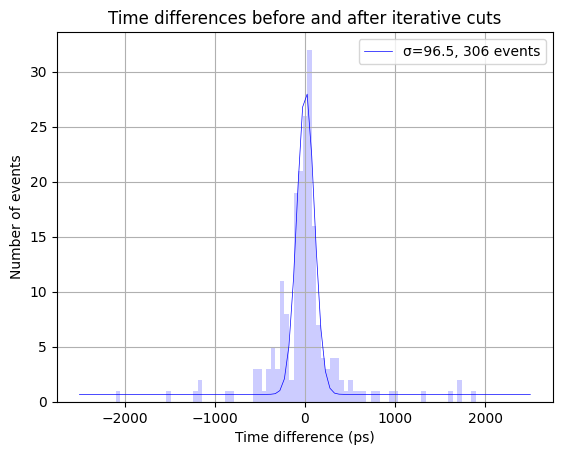

In [202]:
bins = np.linspace(-2500, 2500, 100)
bincenters = [(bins[n] + bins[n + 1]) / 2 for n in range(len(bins) - 1)]
#hist = plt.hist(data[:, 2], bins = bins, color = 'red', alpha = 0.2)[0]
#popt, pcov = curve_fit(gaussianbg, bincenters, hist, p0 = [10, 0, 500, 10])
#plt.plot(bins, gaussianbg(bins, *popt), color = 'red', linewidth = 0.5, label = f'mu = {popt[1]}, σ={abs(round(popt[2], 1))}')
#plt.plot(bins, gaussianbg(bins, *popt), color = 'red', linewidth = 0.5, label = f'σ={abs(round(popt[2], 1))}, {len(data)} events')
hist = plt.hist(data_copy[:, 2], bins = bins, color = 'blue', alpha = 0.2)[0]
popt, pcov = curve_fit(gaussianbg, bincenters, hist, p0 = [10, 0, 500, 10])
#plt.plot(bins, gaussianbg(bins, *popt), color = 'blue', linewidth = 0.5, label = f'mu = {popt[1]}, σ={abs(round(popt[2], 1))}')
plt.plot(bins, gaussianbg(bins, *popt), color = 'blue', linewidth = 0.5, label = f'σ={abs(round(popt[2], 1))}, {len(data_copy)} events')
plt.legend()
plt.grid()
plt.title('Time differences before and after iterative cuts')
plt.xlabel('Time difference (ps)')
plt.ylabel('Number of events')
plt.show()


/tmp/ipykernel_111740/2031372029.py:13: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(gaussianbg, bincenters, hist)
/tmp/ipykernel_111740/2031372029.py:23: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(gaussianbg, bincenters, hist)


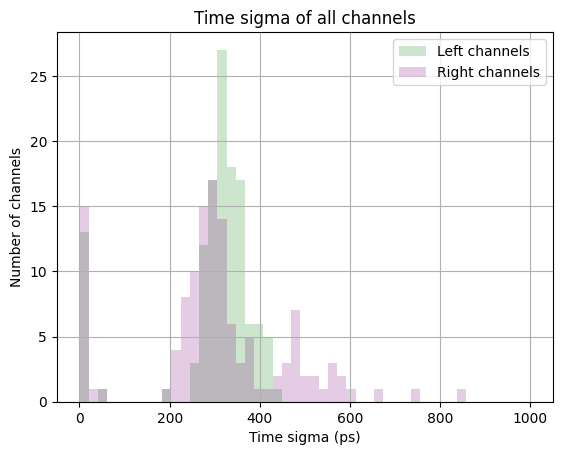

In [203]:
bins = np.linspace(-10000, 10000, 100)
bincenters = [(bins[n] + bins[n + 1]) / 2 for n in range(len(bins) - 1)]

data_copy = data.copy()


time_spreads_L = np.zeros(128)
# Standard deviation of the time distributions from each channel
for i in range(128):
    channelL = data_copy[data_copy[:, 0] == i]
    if len(channelL) > 0:
        hist = np.histogram(channelL[:, 2], bins = bins)[0]
        popt, pcov = curve_fit(gaussianbg, bincenters, hist)
        time_spreads_L[i] = popt[2]
    else:
        time_spreads_L[i] = 0

time_spreads_R = np.zeros(128)
for i in range(128):
    channelR = data_copy[data_copy[:, 1] == i]
    if len(channelR) > 0:
        hist = np.histogram(channelR[:, 2], bins = bins)[0]
        popt, pcov = curve_fit(gaussianbg, bincenters, hist)
        time_spreads_R[i] = popt[2]
    else:
        time_spreads_R[i] = 0

plt.hist(time_spreads_L, bins = np.linspace(0, 1000, 50), color = 'green', alpha = 0.2, label = 'Left channels')
plt.hist(time_spreads_R, bins = np.linspace(0, 1000, 50), color = 'purple', alpha = 0.2, label = 'Right channels')
plt.xlabel('Time sigma (ps)')
plt.ylabel('Number of channels')
plt.title('Time sigma of all channels')
plt.legend()
plt.grid()
plt.show()

In [ ]:
plt.hist(time_spreads_L, bins = np.linspace(0, 1000, 50), color = 'green', alpha = 0.2, label = 'Left channels')
plt.hist(time_spreads_R, bins = np.linspace(0, 1000, 50), color = 'purple', alpha = 0.2, label = 'Right channels')
plt.xlabel('Time sigma (ns)')
plt.ylabel('Number of channels')
plt.title('Time sigma of all channels')
plt.legend()
plt.grid()
plt.show()